# Multi-Element DG Advection: h-Refinement Convergence

**Status:** ✅ **VECTORIZED MULTI-ELEMENT ARCHITECTURE** (2026-04-10)

**Reference Framework:** Hesthaven-Warburton (HW) standard **[-1,1]×[-1,1]** simplex

**Computational Strategy:** Fully vectorized (NO element loops), h-refinement convergence validation

## 🎯 Blueprint Compliance

This notebook strictly adheres to the Multi-Element DG architectural blueprint:

1. **Data Structures**:
   - Global state: `Q` with shape `(n_var, Np, K)` where `n_var=1` (scalar advection)
   - Geometric metrics: `J, rx, ry, sx, sy` as 1D arrays of shape `(K,)`
   - Interface topology: `vmapM` (interior), `vmapP` (exterior with [::-1] reversal), `mapB` (boundary mask)

2. **Absolute Vectorization**:
   - Zero `for k in range(K)` loops in RHS computation
   - All operations use NumPy broadcasting: `rx[np.newaxis, :]` for shape `(Np, K)`

3. **Exact LSRK54 Time Stepping**:
   - Global CFL: `dt_global = CFL * min(h_min_array) / (V_max * N²)`
   - Precise stopping: `while t < t_final - tol` with `current_dt = min(dt_global, t_final - t)`

4. **Convergence Validation**:
   - h-refinement loop over multiple mesh resolutions
   - Pandas DataFrame output with standardized formatting
   - Expected: $O(h^{k+1})$ spatial convergence

## 📐 Problem Formulation

**Scalar Transport Equation:**
$$\frac{\partial q}{\partial t} + \boldsymbol{V} \cdot \nabla q = 0$$

**Test Case:** Dynamic wave $q_\text{exact}(x,y,t) = \sin(x - t)$ with $\boldsymbol{V} = (1, 0)$ (pure x-advection).

## 📚 References

1. Cockburn et al. (2000). *Runge-Kutta Discontinuous Galerkin Methods*
2. Hesthaven & Warburton (2008). *Nodal DG Methods*

In [108]:
# ============================================================================
# CELL 1: Imports, Mesh Generation, Topological Connectivity
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
import sys
import sympy as sp

# Add src to path
notebook_dir = Path("/Users/user/code/Simplex-DG-solver/notebooks/experimental")
project_root = notebook_dir.parent.parent
sys.path.insert(0, str(project_root))

# Import core utilities
from src.core.generators import get_reference_data
from src.core.connectivity import build_connectivity
from src.geometry.metrics import compute_geometric_factors
from src.bases.simplex_2d import generate_subdivided_triangle
from src.reconstruction.boundary import build_fmask_table1

# ============================================================================
# CONFIGURATION: Polynomial Degree & Reference Element
# ============================================================================

k = 4  # Polynomial degree
N = k + 1  # Order parameter
CFL = 1.0  # Global CFL number

# Get reference element data
ref_data = get_reference_data('table1', k)
xi_ref = ref_data['xi']
eta_ref = ref_data['eta']
weights_ref = ref_data['weights']
weights_1d = ref_data['weights_1d']
Np = len(xi_ref)  # Nodes per element

print(f"Reference Element Configuration:")
print(f"  Polynomial degree: k = {k}")
print(f"  Nodes per element: Np = {Np}")
print(f"  1D boundary weights (nfp): {weights_1d}")

# ============================================================================
# CONFIGURATION: Physics Expressions (Single Source of Truth)
# ============================================================================

x, y, t = sp.symbols('x y t')

# Exact solution expression
q_expr = sp.sin(np.pi * (x + y - 2 * t))

# Velocity field expressions
u_expr = sp.sympify(1)
v_expr = sp.sympify(1)

# Compile symbolic expressions to NumPy-callable functions
q_exact_func = sp.lambdify((x, y, t), q_expr, "numpy")
u_func_raw = sp.lambdify((x, y, t), u_expr, "numpy")
v_func_raw = sp.lambdify((x, y, t), v_expr, "numpy")

# ============================================================================
# FUNCTION: Mesh Generation & Connectivity
# ============================================================================

def generate_and_build_mesh(n_div):
    """
    Generate a subdivided reference triangle mesh and build connectivity.

    Args:
        n_div: Subdivision parameter (e.g., n_div=1 gives 1 element, n_div=2 gives 4 elements)

    Returns:
        nodes: Global nodal coordinates (n_physical_nodes, 2)
        EToV: Element-to-Vertex connectivity (K, 3)
        EToE, EToF: Connectivity matrices
        K: Total number of elements
    """
    # Generate mesh
    nodes, triangles = generate_subdivided_triangle(n_div)
    nodes = (nodes + 1.0) / 2.0  # Scale to [0,1]x[0,1]
    EToV = np.array(triangles, dtype=int)
    K = len(EToV)

    # Build connectivity
    EToE, EToF = build_connectivity(EToV)

    print(f"  n_div={n_div}: K={K} elements, {len(nodes)} physical nodes")

    return nodes, EToV, EToE, EToF, K

# ============================================================================
# FUNCTION: Global Index Maps (vmapM, vmapP, mapB)
# ============================================================================

def build_global_index_maps(EToV, EToE, EToF, ri_ref, si_ref):
    """
    Build global interface node index maps: vmapM (interior), vmapP (exterior), mapB (boundary).

    Critical Rule: Adjacent face nodes are strictly reversed [::-1] due to CCW ordering.

    Args:
        EToV, EToE, EToF: Connectivity matrices
        ri_ref, si_ref: Reference element barycentric coordinates

    Returns:
        vmapM: (3*nfp, K) - interior node indices
        vmapP: (3*nfp, K) - exterior node indices (with reversal)
        mapB: List of boundary node indices in flattened Q
    """
    nfp = len(weights_1d)  # Nodes per face
    K = len(EToV)

    # Compute barycentric coordinates
    bary_coords = np.column_stack([
        (-ri_ref - si_ref) / 2,
        (ri_ref + 1) / 2,
        (si_ref + 1) / 2
    ])

    # Extract boundary node indices per face using API
    fmask = build_fmask_table1(bary_coords)  # Shape: (nfp, 3)

    # Initialize maps
    vmapM = np.zeros((3 * nfp, K), dtype=int)
    vmapP = np.zeros((3 * nfp, K), dtype=int)
    mapB_list = []

    # Build vmapM and vmapP for each element and face
    for k in range(K):
        for f in range(3):
            # Local node indices on face f of element k
            local_nodes = fmask[:, f]

            # Global indices (interior)
            interior_indices = k * Np + local_nodes
            vmapM[f * nfp:(f + 1) * nfp, k] = interior_indices

            # Find neighbor element and face
            k_neighbor = EToE[k, f]
            f_neighbor = EToF[k, f]

            if k_neighbor == k:
                # This is a boundary face
                vmapP[f * nfp:(f + 1) * nfp, k] = interior_indices
                # Record indices in flattened vmapP array that correspond to boundaries
                # When vmapP (3*nfp, K) is flattened to 1D, element at vmapP[i,k] appears at index i*K + k
                for jj in range(nfp):
                    mapB_list.append((f * nfp + jj) * K + k)
            else:
                # Interior face: get neighbor nodes with REVERSAL
                neighbor_local_nodes = fmask[:, f_neighbor]
                neighbor_indices = k_neighbor * Np + neighbor_local_nodes
                # Critical reversal rule
                vmapP[f * nfp:(f + 1) * nfp, k] = neighbor_indices[::-1]

    mapB = np.array(sorted(set(mapB_list)), dtype=int)

    print(f"  Global index maps built: vmapM {vmapM.shape}, vmapP {vmapP.shape}")
    print(f"  Boundary nodes: {len(mapB)}")

    return vmapM, vmapP, mapB, fmask

# ============================================================================
# FUNCTION: Compute Geometric Metrics (K,)
# ============================================================================

def compute_metrics_vectorized(nodes, EToV):
    """
    Compute geometric metrics for all elements as 1D arrays of shape (K,).

    Returns:
        J: Jacobian determinants (K,)
        rx, ry, sx, sy: Transformation coefficients (K,)
        h_min: Characteristic element sizes (K,)
    """
    K = len(EToV)
    J_array = np.zeros(K)
    rx_array = np.zeros(K)
    ry_array = np.zeros(K)
    sx_array = np.zeros(K)
    sy_array = np.zeros(K)
    h_min_array = np.zeros(K)

    for k in range(K):
        v1, v2, v3 = nodes[EToV[k]]
        metrics = compute_geometric_factors(v1, v2, v3)
        J_array[k] = metrics['J']
        rx_array[k] = metrics['rx']
        ry_array[k] = metrics['ry']
        sx_array[k] = metrics['sx']
        sy_array[k] = metrics['sy']

        # Characteristic length: inscribed circle diameter
        edge_lengths = np.array([
            np.linalg.norm(v2 - v1),
            np.linalg.norm(v3 - v2),
            np.linalg.norm(v1 - v3)
        ])
        perimeter = np.sum(edge_lengths)
        area = metrics['J'] / 2.0
        h_min_array[k] = 2.0 * area / (perimeter / 2.0)

    return J_array, rx_array, ry_array, sx_array, sy_array, h_min_array

Reference Element Configuration:
  Polynomial degree: k = 4
  Nodes per element: Np = 22
  1D boundary weights (nfp): [0.23692689 0.47862867 0.56888889 0.47862867 0.23692689]


In [109]:
# ============================================================================
# CELL 2: Initialization of Operators, Metrics, and Global State Q
# ============================================================================

from src.bases.vandermonde import vandermonde_2d_dubiner, grad_vandermonde_2d_dubiner
from src.reconstruction import build_differentiation_matrices

# ============================================================================
# FUNCTION: Initialize Multi-Element DG Operators & State
# ============================================================================

def initialize_multi_element_dg(nodes, EToV, K):
    """
    Initialize all operators for multi-element DG solver.

    Returns:
        D_r_ref, D_s_ref: Reference differentiation matrices (Np, Np)
        E: Boundary extraction matrix (3*nfp, Np)
        weights_2d: 2D integration weights (Np,) for mass lumping
        X, Y: Physical coordinates (Np, K)
        J, rx, ry, sx, sy, h_min_array: Geometric metrics
    """
    nfp = len(weights_1d)

    # Build reference Vandermonde & differentiation matrices
    V_nodal = vandermonde_2d_dubiner(xi_ref, eta_ref, k)
    Vr, Vs = grad_vandermonde_2d_dubiner(xi_ref, eta_ref, k)
    D_r_ref, D_s_ref = build_differentiation_matrices(V_nodal, Vr, Vs, w=weights_ref)

    W = np.diag(weights_ref)
    M_modal = V_nodal.T @ W @ V_nodal

    # 計算其反矩陣供 RHS 使用
    M_inv_projected = V_nodal @ np.linalg.inv(M_modal) @ V_nodal.T

    # Extract boundary nodes per face
    bary_coords = np.column_stack([
        (-xi_ref - eta_ref) / 2,
        (xi_ref + 1) / 2,
        (eta_ref + 1) / 2
    ])
    fmask = build_fmask_table1(bary_coords)

    # Build boundary extraction matrix E (reference element)
    E = np.zeros((3 * nfp, Np))
    for f in range(3):
        for j, node_idx in enumerate(fmask[:, f]):
            E[f * nfp + j, node_idx] = 1.0

    # Compute geometric metrics for all elements
    J, rx, ry, sx, sy, h_min_array = compute_metrics_vectorized(nodes, EToV)

    # Store reference operators (will be applied with broadcasting rx, ry, sx, sy in RHS)
    # Store integration weights for mass-lumping formula (returned as is, not scaled)
    # Scaling by J will be done in RHS computation for each element individually

    # Compute physical coordinates for all elements
    X = np.zeros((Np, K))
    Y = np.zeros((Np, K))

    for k_elem in range(K):
        v1, v2, v3 = nodes[EToV[k_elem]]
        # HW affine mapping
        x_phys = -0.5 * (xi_ref + eta_ref) * v1[0] + 0.5 * (xi_ref + 1) * v2[0] + 0.5 * (eta_ref + 1) * v3[0]
        y_phys = -0.5 * (xi_ref + eta_ref) * v1[1] + 0.5 * (xi_ref + 1) * v2[1] + 0.5 * (eta_ref + 1) * v3[1]
        X[:, k_elem] = x_phys
        Y[:, k_elem] = y_phys

    print(f"Multi-Element DG Operators Initialized:")
    print(f"  D_r_ref shape: {D_r_ref.shape}")
    print(f"  E (boundary extraction) shape: {E.shape}")
    print(f"  weights_2d (integration weights) shape: {weights_ref.shape}")
    print(f"  X, Y physical coordinates shape: {X.shape}")

    return D_r_ref, D_s_ref, E, fmask, weights_ref, X, Y, J, rx, ry, sx, sy, h_min_array, M_inv_projected

In [110]:
# ============================================================================
# CELL 3: Vectorized RHS Computation (NO Element Loops)
# ============================================================================

# ============================================================================
# PHYSICS FUNCTIONS
# ============================================================================

def exact_solution_multi(X, Y, t):
    """
    Exact solution dynamically evaluated from SymPy expression.
    """
    return q_exact_func(X, Y, t)


def velocity_field_multi(X, Y, t):
    """
    Velocity field dynamically evaluated from SymPy expressions.

    Uses np.broadcast_to so constant expressions (e.g., 1 or 0)
    still return arrays with shape (Np, K).
    """
    u_arr = np.broadcast_to(u_func_raw(X, Y, t), X.shape)
    v_arr = np.broadcast_to(v_func_raw(X, Y, t), X.shape)
    return u_arr, v_arr

def compute_rhs_vectorized(Q, X, Y, D_r_ref, D_s_ref, E, fmask, rx, ry, sx, sy,
                           vmapM, vmapP, weights_2d, J, weights_1d, nx_expanded, ny_expanded,
                           J_face_expanded, K, y1_bc, boundary_mask, M_inv_projected):
    """
    Compute RHS using ABSOLUTE VECTORIZATION (no for loops over elements).

    Uses STRICT MASS-LUMPING FORMULA with SYNCHRONIZED BOUNDARY CONDITIONS:
    surface_term = (1 / |T|) * W_inv @ E_T @ W_e @ p
    where boundary values are integrated via coupled ODE system.

    Args:
        Q: State tensor (1, Np, K) - n_var=1 for scalar advection
        X, Y: Physical coordinates (Np, K)
        y1_bc: Synchronized boundary state (3*nfp, K), integrated via ODE
        boundary_mask: Boolean mask (3*nfp, K) indicating boundary nodes
        M_inv_projected: Inverse mass matrix (Np, Np)

    Returns:
        RHS: dQ/dt tensor (1, Np, K)
    """
    nfp = len(weights_1d)

    # Extract scalar field from state tensor
    q = Q[0]  # Shape: (Np, K)

    # DEBUG: Verify input shapes
    assert D_r_ref.ndim == 2, f"D_r_ref must be 2D, got shape {D_r_ref.shape}"
    assert D_s_ref.ndim == 2, f"D_s_ref must be 2D, got shape {D_s_ref.shape}"
    assert q.ndim == 2, f"q must be 2D (Np, K), got shape {q.shape}"
    assert rx.ndim == 1, f"rx must be 1D (K,), got shape {rx.shape}"

    # ========================================================================
    # VOLUME TERM (Vectorized - No Loops)
    # ========================================================================

    # Evaluate velocity field (time-independent for this problem)
    u_arr, v_arr = velocity_field_multi(X, Y, 0.0)  # Shape: (Np, K)

    # Reference derivatives
    dq_dr = D_r_ref @ q  # (Np, K) via broadcasting
    dq_ds = D_s_ref @ q  # (Np, K)

    # Physical derivatives with broadcasting
    dq_dx = rx[np.newaxis, :] * dq_dr + sx[np.newaxis, :] * dq_ds  # (Np, K)
    dq_dy = ry[np.newaxis, :] * dq_dr + sy[np.newaxis, :] * dq_ds  # (Np, K)

    # Split-Form volume term (vectorized)
    duq_dr = D_r_ref @ (u_arr * q)  # (Np, K)
    duq_ds = D_s_ref @ (u_arr * q)  # (Np, K)
    dvq_dr = D_r_ref @ (v_arr * q)  # (Np, K)
    dvq_ds = D_s_ref @ (v_arr * q)  # (Np, K)

    # Apply chain rule to get term1 = D_x(u*q) + D_y(v*q)
    term1_x = rx[np.newaxis, :] * duq_dr + sx[np.newaxis, :] * duq_ds  # (Np, K)
    term1_y = ry[np.newaxis, :] * dvq_dr + sy[np.newaxis, :] * dvq_ds  # (Np, K)
    term1 = term1_x + term1_y  # (Np, K)

    # term2 = u*(D_x q) + v*(D_y q)
    term2 = u_arr * dq_dx + v_arr * dq_dy  # (Np, K)

    # term3 = (D_x u + D_y v)*q
    du_dx = rx[np.newaxis, :] * (D_r_ref @ u_arr) + sx[np.newaxis, :] * (D_s_ref @ u_arr)  # (Np, K)
    dv_dy = ry[np.newaxis, :] * (D_r_ref @ v_arr) + sy[np.newaxis, :] * (D_s_ref @ v_arr)  # (Np, K)
    term3 = (du_dx + dv_dy) * q  # (Np, K)

    # Combine volume term (all terms are (Np, K))
    volume_term = -0.5 * (term1 + term2 + term3)  # (Np, K)

    # ========================================================================
    # SURFACE TERM (Vectorized - No Loops)
    # ========================================================================

    # Extract boundary values (CRITICAL: use order='F' for Fortran indexing)
    q_flat = q.flatten(order='F')  # Flatten to 1D for indexing (Np*K,)
    q_M = q_flat[vmapM]  # Interior values (3*nfp, K)
    q_P = q_flat[vmapP].copy()  # Exterior values (3*nfp, K)

    # ========================================================================
    # APPLY SYNCHRONIZED BOUNDARY CONDITIONS (ODE Integration)
    # ========================================================================
    # Replace q_P at boundaries with RK-integrated boundary state
    # boundary_mask is True only at domain boundaries
    q_P[boundary_mask] = y1_bc[boundary_mask]

    # Compute interface normal velocities using exact normals
    u_boundary = u_arr.flatten(order='F')[vmapM]  # (3*nfp, K)
    v_boundary = v_arr.flatten(order='F')[vmapM]  # (3*nfp, K)
    v_normal = nx_expanded * u_boundary + ny_expanded * v_boundary  # (3*nfp, K)

    # Branchless upwind flux
    upwind_factor = 0.5 * (v_normal - np.abs(v_normal))  # (3*nfp, K)
    flux_penalty = upwind_factor * (q_M - q_P)  # (3*nfp, K)

    # Apply 1D weights and face Jacobian
    face_w = np.tile(weights_1d, 3)  # (3*nfp,)
    scaled_penalty = flux_penalty * face_w[:, np.newaxis] * J_face_expanded  # (3*nfp, K)

    # ========================================================================
    # ASSEMBLE SURFACE TERM (Strict Mass-Lumping Formula)
    # ========================================================================

    # Step 1: E^T @ W_e @ p
    surface_integral = E.T @ scaled_penalty  # (Np, K)

    # Step 2: Construct W_inv (diagonal inverse of weights)
    W_inv = 1.0 / weights_2d  # (Np,)

    # Step 3: Final Assembly: (1 / |T|) * W_inv @ (E^T @ W_e @ p)
    # surface_term = (1.0 / J[np.newaxis, :]) * (W_inv[:, np.newaxis] * surface_integral)
    surface_term = (1.0 / J[np.newaxis, :]) * (M_inv_projected @ surface_integral)  # (Np, K)

    # ========================================================================
    # FINAL RHS
    # ========================================================================

    # Combine volume and surface terms
    rhs_q = volume_term + surface_term  # (Np, K)

    # Reshape back to (1, Np, K) state tensor
    RHS = rhs_q[np.newaxis, :, :]  # (1, Np, K)

    return RHS

In [111]:
# ============================================================================
# CELL 4: Convergence Loop with Synchronized LSRK54 Time Stepping & Boundary ODE
# ============================================================================

# LSRK54 Coefficients (Carpenter & Kennedy 1994)
A_RK = np.array([0.0,
                 -567301805773.0/1357537059087.0,
                 -2404267990393.0/2016746695238.0,
                 -3550918686646.0/2091501179385.0,
                 -1275806237668.0/842570457699.0])
B_RK = np.array([1432997174477.0/9575080441755.0,
                 5161836677717.0/13612068292357.0,
                 1720146321549.0/2090206949498.0,
                 3134564353537.0/4481467310338.0,
                 2277821191437.0/14882151754819.0])
C_RK = np.array([0.0,
                 0.1496590219993,
                 0.3704009573644,
                 0.6222557631345,
                 0.9582818314695])

# ============================================================================
# HELPER FUNCTIONS: Exact Boundary Time Derivatives
# ============================================================================

g_expr     = q_expr
g_t_expr   = sp.diff(q_expr, t)
g_tt_expr  = sp.diff(q_expr, t, 2)
g_ttt_expr = sp.diff(q_expr, t, 3)
g_func     = sp.lambdify((x, y, t), g_expr, "numpy")
g_t_func   = sp.lambdify((x, y, t), g_t_expr, "numpy")
g_tt_func  = sp.lambdify((x, y, t), g_tt_expr, "numpy")
g_ttt_func = sp.lambdify((x, y, t), g_ttt_expr, "numpy")

def exact_boundary_solution(X_bc, Y_bc, time_t):
    return (
        g_func(X_bc, Y_bc, time_t),
        g_t_func(X_bc, Y_bc, time_t),
        g_tt_func(X_bc, Y_bc, time_t),
        g_ttt_func(X_bc, Y_bc, time_t),
    )


def compute_boundary_rhs_vectorized(g_bc, X_bc, Y_bc, time_t, boundary_mask):
    """
    Compute RHS of boundary ODE system using synchronized time derivatives.

    State vector: g_bc = [g, g_t, g_tt]^T with shape (3, N_bc) where N_bc = number of boundary nodes
    RHS: dg_bc/dt = [g_t, g_tt, g_ttt]^T where g_ttt is computed exactly

    Vectorized entirely over boundary nodes (no loops).

    Args:
        g_bc: Boundary state array, shape (3, N_bc)
        X_bc: x-coordinates at boundary, shape matching boundary_mask
        Y_bc: y-coordinates at boundary, shape matching boundary_mask
        time_t: Current time (scalar)
        boundary_mask: Boolean array to extract boundary values from global arrays

    Returns:
        R_bc: RHS vector, shape (3, N_bc)
    """
    # Extract boundary nodes count
    N_bc = g_bc.shape[1]

    # Compute exact g_ttt at current time
    _, _, _, g_ttt_exact = exact_boundary_solution(X_bc, Y_bc, time_t)

    # Construct RHS: [g_t, g_tt, g_ttt]
    # R_bc[0] = g_t (from state)
    # R_bc[1] = g_tt (from state)
    # R_bc[2] = g_ttt (compute exactly)
    R_bc = np.zeros((3, N_bc))
    R_bc[0] = g_bc[1]  # dg/dt = g_t
    R_bc[1] = g_bc[2]  # dg_t/dt = g_tt
    R_bc[2] = g_ttt_exact.ravel()  # dg_tt/dt = g_ttt (exact evaluation)

    return R_bc

# ============================================================================
# FUNCTION: 追蹤固定 n_div 下，誤差隨時間的演化
# ============================================================================

def run_time_error_tracking(n_div=3, t_final=1.0, CFL=1.0):
    print(f"\n{'='*70}")
    print(f"Time Error Tracking: 固定 n_div = {n_div}")
    print(f"{'='*70}")

    # 1. 建立網格與拓樸
    nodes, EToV, EToE, EToF, K = generate_and_build_mesh(n_div)
    vmapM, vmapP, mapB, fmask = build_global_index_maps(EToV, EToE, EToF, xi_ref, eta_ref)

    # 2. 初始化算子與幾何矩陣
    (D_r_ref, D_s_ref, E, fmask_ref, weights_2d, X, Y,
     J, rx, ry, sx, sy, h_min_array, M_inv_projected) = initialize_multi_element_dg(nodes, EToV, K)

    # 用於計算 L2 誤差的質量矩陣對角項
    M_diag = weights_2d[:, np.newaxis] * J[np.newaxis, :]

    # 3. 計算確切的邊緣法向量與面積 Jacobian
    nfp = len(weights_1d)
    J_face = np.zeros((3, K))
    nx_array = np.zeros((3, K))
    ny_array = np.zeros((3, K))

    for k_elem in range(K):
        v1, v2, v3 = nodes[EToV[k_elem]]
        edges = [v2 - v1, v3 - v2, v1 - v3]
        for f in range(3):
            dx, dy = edges[f]
            length = np.hypot(dx, dy)
            J_face[f, k_elem] = length / 2.0
            nx_array[f, k_elem] = dy / length
            ny_array[f, k_elem] = -dx / length

    J_face_expanded = np.repeat(J_face, nfp, axis=0)
    nx_expanded = np.repeat(nx_array, nfp, axis=0)
    ny_expanded = np.repeat(ny_array, nfp, axis=0)

    # 4. 初始化狀態 Q (t=0)
    q_init = exact_solution_multi(X, Y, t=0.0)
    Q = q_init[np.newaxis, :, :]

    # 5. 準備同步邊界 ODE 系統
    boundary_mask = (vmapM == vmapP)
    X_flat = X.flatten(order='F')
    Y_flat = Y.flatten(order='F')
    X_bc = X_flat[vmapP][boundary_mask]
    Y_bc = Y_flat[vmapP][boundary_mask]

    N_bc = len(X_bc)
    g_bc = np.zeros((3, N_bc))
    g_vals, g_t_vals, g_tt_vals, _ = exact_boundary_solution(X_bc, Y_bc, time_t=0.0)
    g_bc[0] = g_vals
    g_bc[1] = g_t_vals
    g_bc[2] = g_tt_vals
    dg_bc = np.zeros_like(g_bc)

    # 6. 計算時間步長 dt
    u_field, v_field = velocity_field_multi(X, Y, 0.0)
    V_magnitude = np.sqrt(u_field**2 + v_field**2)
    V_max = np.max(V_magnitude)
    dt_global = CFL * np.min(h_min_array) / (V_max * N**2)

    print(f"Global CFL: dt = {dt_global:.6e}")

    # ====================================================================
    # NEW: 建立用於儲存歷史紀錄的串列
    # ====================================================================
    time_history = []
    l2_history = []
    linf_history = []

    # 7. 時間積分迴圈
    t = 0.0
    tol = 1e-12
    du = np.zeros_like(Q)
    step_count = 0

    while t < t_final - tol:
        current_dt = min(dt_global, t_final - t)
        du.fill(0.0)
        dg_bc.fill(0.0)

        # LSRK54 5-stages
        for stage in range(5):
            current_stage_time = t + C_RK[stage] * current_dt

            # 更新邊界 ODE RHS
            R_bc = compute_boundary_rhs_vectorized(g_bc, X_bc, Y_bc, current_stage_time, boundary_mask)
            boundary_state_for_pde = np.zeros((3 * nfp, K))
            boundary_state_for_pde[boundary_mask] = g_bc[0]

            # 更新主 PDE RHS
            R_Q = compute_rhs_vectorized(Q, X, Y, D_r_ref, D_s_ref, E, fmask_ref,
                                        rx, ry, sx, sy, vmapM, vmapP, weights_2d, J,
                                        weights_1d, nx_expanded, ny_expanded, J_face_expanded, K,
                                        boundary_state_for_pde, boundary_mask, M_inv_projected)

            # 同步推進
            dg_bc = A_RK[stage] * dg_bc + current_dt * R_bc
            g_bc = g_bc + B_RK[stage] * dg_bc
            du = A_RK[stage] * du + current_dt * R_Q
            Q = Q + B_RK[stage] * du

        t += current_dt
        step_count += 1

        # ====================================================================
        # NEW: 在每一步結束時計算誤差，並記錄下來
        # ====================================================================
        Q_exact_current = exact_solution_multi(X, Y, t)[np.newaxis, :, :]
        error_field = (Q - Q_exact_current)[0]

        l2_error = np.sqrt(np.sum(error_field**2 * M_diag))
        linf_error = np.max(np.abs(error_field))

        time_history.append(t)
        l2_history.append(l2_error)
        linf_history.append(linf_error)

        # 為了避免輸出過多，這裡每一百步印出一次
        if step_count % 100 == 0:
             print(f"  Step {step_count}: t = {t:.6f}/{t_final:.6f} | L2 Err: {l2_error:.4e}")

    print(f"Final time reached: t = {t:.6f}, {step_count} steps")
    return time_history, l2_history, linf_history

# 執行測試 (設定 n_div = 3)
# t_hist, l2_hist, linf_hist = run_time_error_tracking(n_div=24, t_final=2.0, CFL=CFL)

In [112]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 5))

# # 繪製 L2 與 L∞ 誤差隨時間變化
# plt.plot(t_hist, l2_hist, label="L2 Error", color="blue", linewidth=1.5)
# plt.plot(t_hist, linf_hist, label="L∞ Error", color="orange", linewidth=1.5)

# # 若誤差隨時間指數增長，可以考慮開啟 log 尺度 (可選)
# plt.yscale('log')

# plt.title('Error Evolution over Time (n_div=32)')
# plt.xlabel('Time (t)')
# plt.ylabel('Error')
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.legend()
# plt.tight_layout()

# plt.show()

In [113]:
# ============================================================================
# 批次執行多個 n_div 並儲存結果
# ============================================================================

# 設定你想要測試的網格分割參數清單
# 注意：n_div 越大，計算時間會呈指數上升，建議先從小數值開始測試
n_div_list = [4, 8, 12, 16]
t_final_sim = 20.0
CFL_sim = 1.0

# 建立一個字典來集中管理所有的歷史紀錄
simulation_results = {}

for n_div in n_div_list:
    print(f"\n>>>>> 開始執行 n_div = {n_div} 的模擬 <<<<<")

    # 呼叫你已經寫好的函數
    t_hist, l2_hist, linf_hist = run_time_error_tracking(n_div=n_div, t_final=t_final_sim, CFL=CFL_sim)

    # 將回傳結果儲存進字典中，以 n_div 為 key
    simulation_results[n_div] = {
        'time': t_hist,
        'l2': l2_hist,
        'linf': linf_hist
    }

print("\n所有模擬執行完畢！")


>>>>> 開始執行 n_div = 4 的模擬 <<<<<

Time Error Tracking: 固定 n_div = 4
  n_div=4: K=16 elements, 15 physical nodes
  Global index maps built: vmapM (15, 16), vmapP (15, 16)
  Boundary nodes: 60
Multi-Element DG Operators Initialized:
  D_r_ref shape: (22, 22)
  E (boundary extraction) shape: (15, 22)
  weights_2d (integration weights) shape: (22,)
  X, Y physical coordinates shape: (22, 16)
Global CFL: dt = 5.177670e-04
  Step 100: t = 0.051777/20.000000 | L2 Err: 6.2969e-08
  Step 200: t = 0.103553/20.000000 | L2 Err: 1.0364e-07
  Step 300: t = 0.155330/20.000000 | L2 Err: 1.4153e-07
  Step 400: t = 0.207107/20.000000 | L2 Err: 1.6808e-07
  Step 500: t = 0.258883/20.000000 | L2 Err: 1.6954e-07
  Step 600: t = 0.310660/20.000000 | L2 Err: 1.5219e-07
  Step 700: t = 0.362437/20.000000 | L2 Err: 1.2184e-07
  Step 800: t = 0.414214/20.000000 | L2 Err: 8.3115e-08
  Step 900: t = 0.465990/20.000000 | L2 Err: 4.9541e-08
  Step 1000: t = 0.517767/20.000000 | L2 Err: 5.5616e-08
  Step 1100: t = 0.

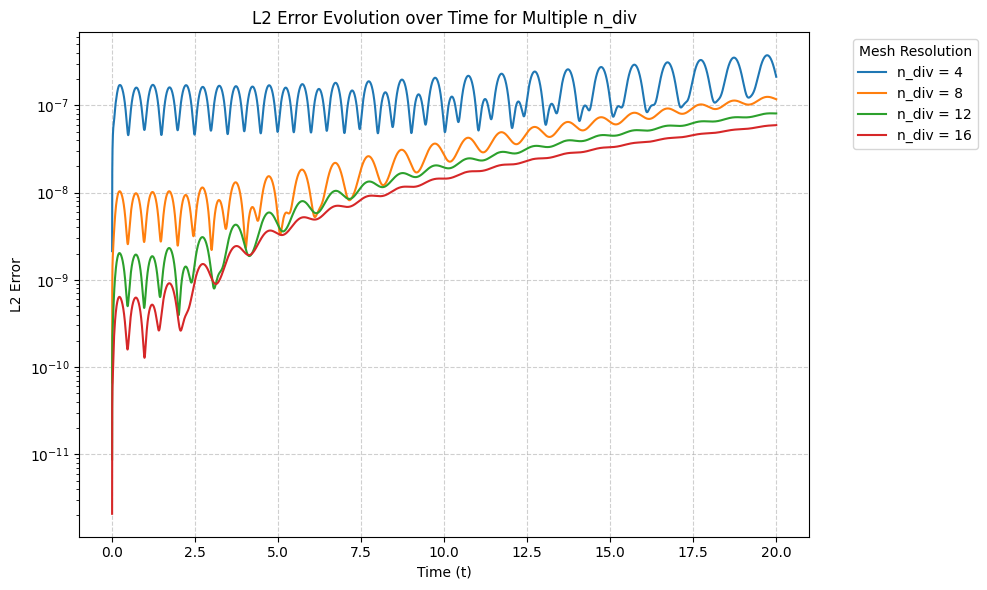

In [114]:
# ============================================================================
# 繪製多重 n_div 的 L2 誤差比較圖
# ============================================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 走訪字典中的每一組設定與資料
for n_div, data in simulation_results.items():
    # 這裡我們只示範畫出 L2 Error，方便畫面保持整潔
    plt.plot(
        data['time'],
        data['l2'],
        label=f"n_div = {n_div}",
        linewidth=1.5
    )

# 開啟對數尺度 (Log Scale) 對於觀察高階 DG 方法的誤差非常重要
plt.yscale('log')

plt.title('L2 Error Evolution over Time for Multiple n_div')
plt.xlabel('Time (t)')
plt.ylabel('L2 Error')
plt.grid(True, linestyle='--', alpha=0.6)

# 將圖例加上標題，放在畫面外側或適當位置
plt.legend(title="Mesh Resolution", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()